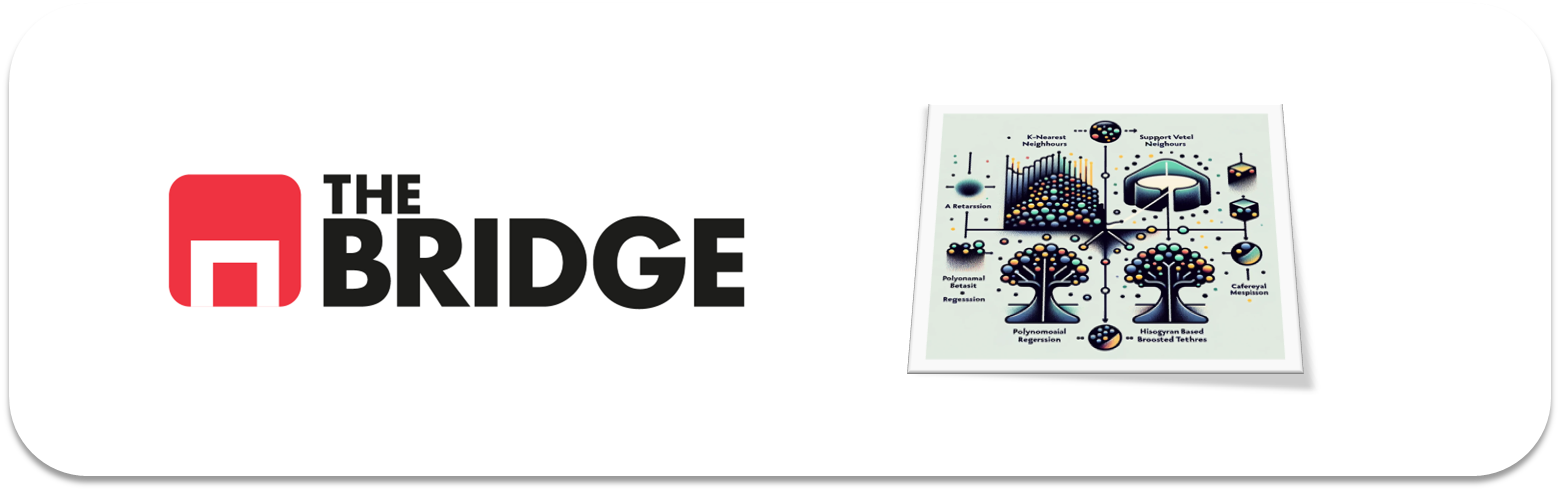

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split


### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('./data/wines_dataset.csv', sep="|")

In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [7]:
# Target de clasificación: calidad del vino
y_class = df['quality']

# Target de regresión: grado alcohólico
y_reg = df['alcohol']

# Variables predictoras (excluyendo ambos targets para no filtrar información entre problemas)
X = df.drop(columns=['quality', 'alcohol'])

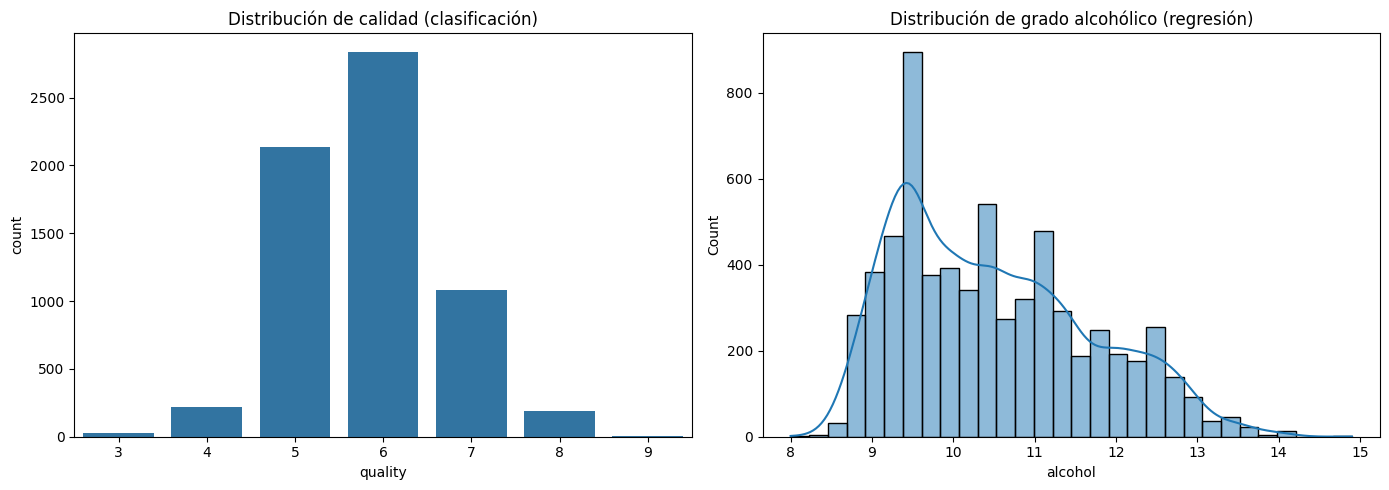

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64
count    6497.000000
mean       10.491801
std         1.192712
min         8.000000
25%         9.500000
50%        10.300000
75%        11.300000
max        14.900000
Name: alcohol, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='quality', ax=axes[0])
axes[0].set_title('Distribución de calidad (clasificación)')

sns.histplot(data=df, x='alcohol', kde=True, ax=axes[1], bins=30)
axes[1].set_title('Distribución de grado alcohólico (regresión)')

plt.tight_layout()
plt.show()

print(df['quality'].value_counts().sort_index())
print(df['alcohol'].describe())

Vemos que hay una infrarrepresentación de las clases de calidad 3, 4, 8 y 9. En cuanto al problema de regresión, la distribución de los valores puede asemejarse a una distribución normal, aunque se explorará la opción de normalizar el dataset.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

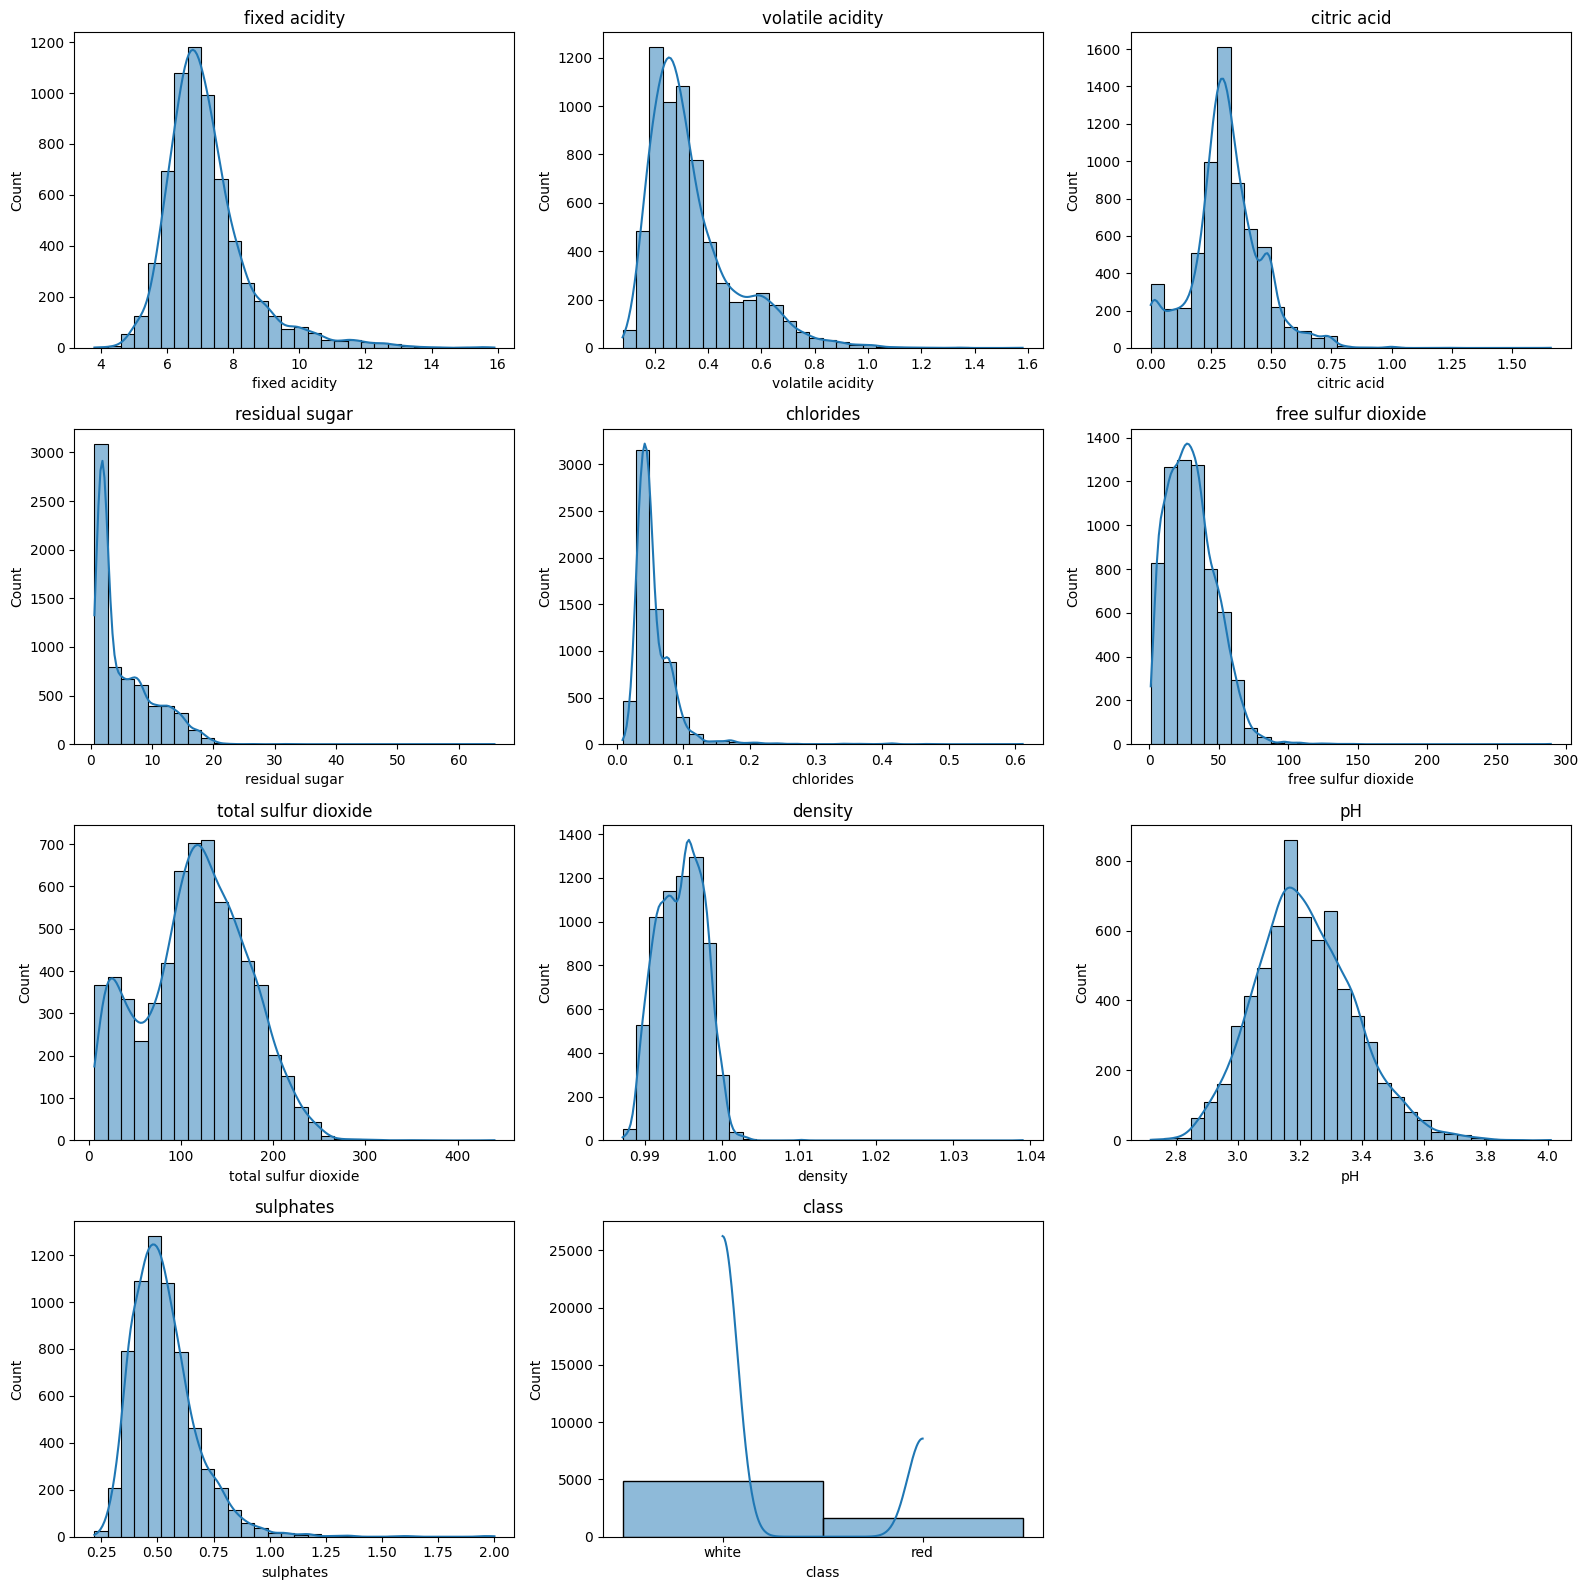

In [9]:
# Distribución de las variables predictoras
num_vars = X.columns.tolist()

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)

# Ocultar subplots vacíos si sobran
for j in range(len(num_vars), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

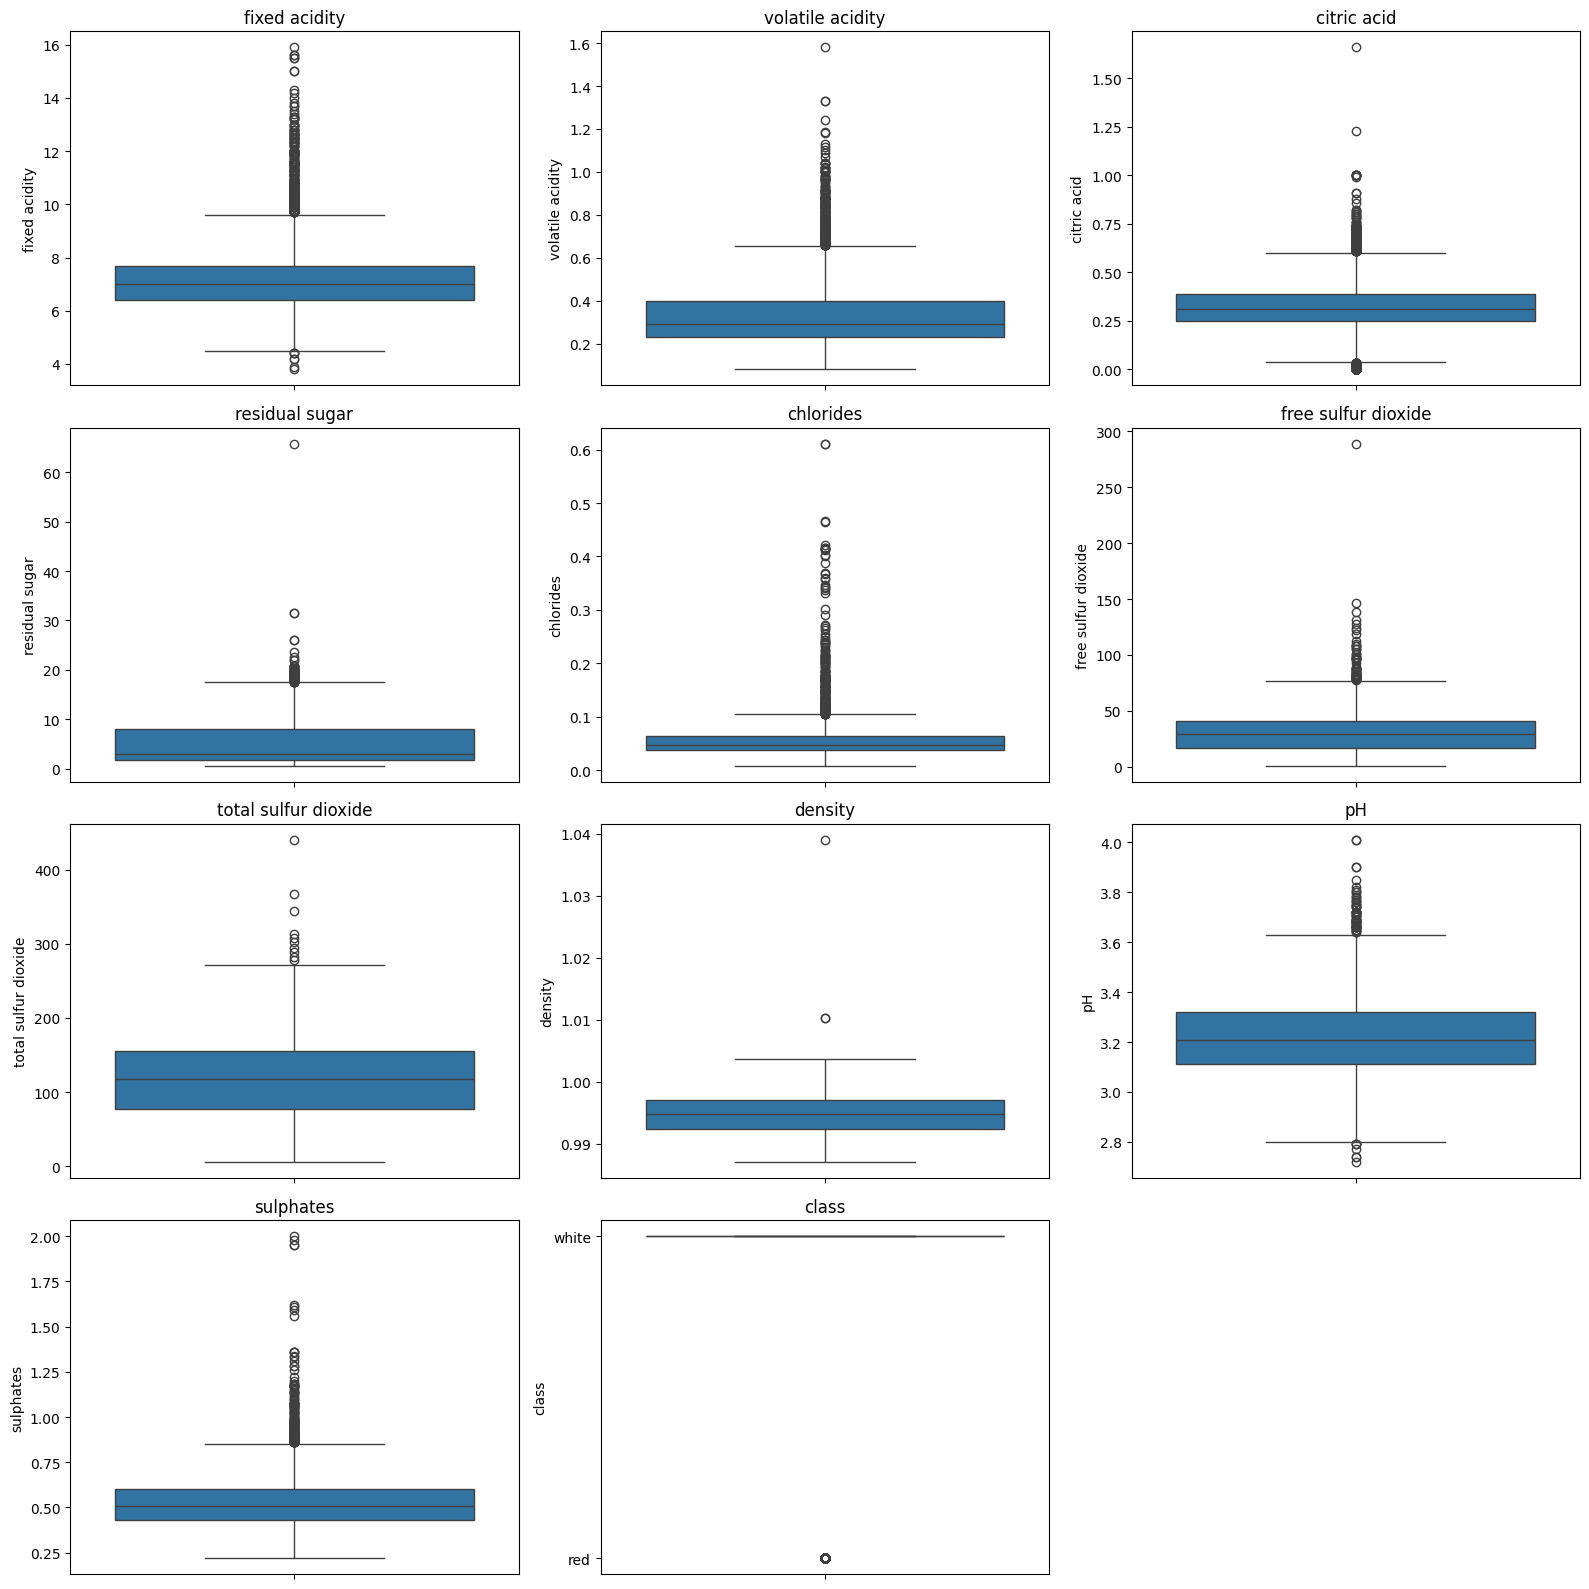

In [10]:
# Boxplots para detectar outliers en las predictoras
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(num_vars), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Vemos que hay una variable categórica que habrá que recodificar para que pueda ser interpretada por todos los modelos. El resto de valores presentan la distribución esperada con pocos valores extremos. Sí que hay una presencia fuerte de outliers en muchas de las variables numéricas.

In [16]:
df['type_encoded'] = df['class'].map({'white': 0, 'red': 1})
df = df.drop(columns='class')

In [14]:
X['type_encoded'] = df['type_encoded']
X = X.drop(columns=['class'])

In [17]:
# Correlación de todas las variables numéricas con ambos targets
corr = df.corr()

print("Correlación con quality:")
print(corr['quality'].sort_values(ascending=False))

print("\nCorrelación con alcohol:")
print(corr['alcohol'].sort_values(ascending=False))

Correlación con quality:
quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
type_encoded           -0.119323
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64

Correlación con alcohol:
alcohol                 1.000000
quality                 0.444319
pH                      0.121248
sulphates              -0.003029
citric acid            -0.010493
type_encoded           -0.032970
volatile acidity       -0.037640
fixed acidity          -0.095452
free sulfur dioxide    -0.179838
chlorides              -0.256916
total sulfur dioxide   -0.265740
residual sugar         -0.359415
density                -0.686745
Name: alcohol, dtype: float64


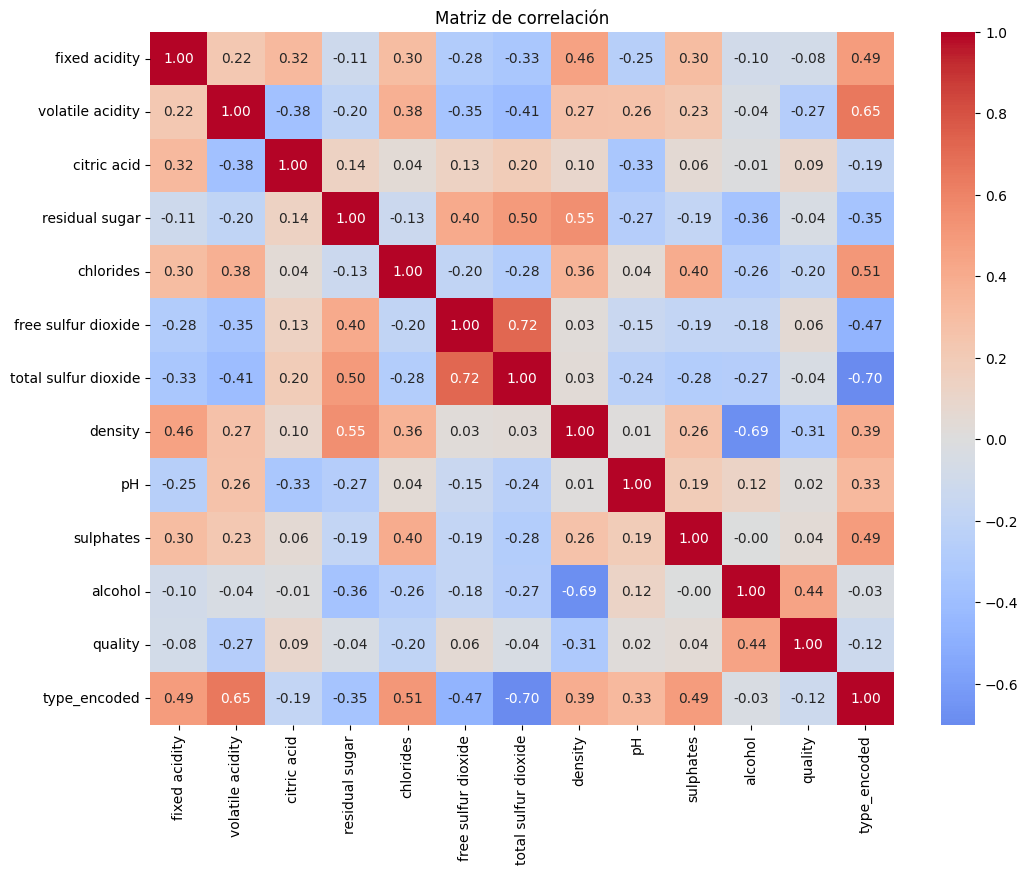

In [18]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

Vemos que no hay correlaciones fuertes (> 80%), así que se mantienen todas las variables.

In [21]:
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg,
    test_size=0.2, random_state=42, stratify=y_class
)

print(X_train.shape, X_test.shape)

(5197, 11) (1300, 11)


In [22]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

cols_a_transformar = [c for c in X_train.columns if c != 'type_encoded']

X_train_pt = X_train.copy()
X_test_pt = X_test.copy()

X_train_pt[cols_a_transformar] = pt.fit_transform(X_train[cols_a_transformar])
X_test_pt[cols_a_transformar] = pt.transform(X_test[cols_a_transformar])

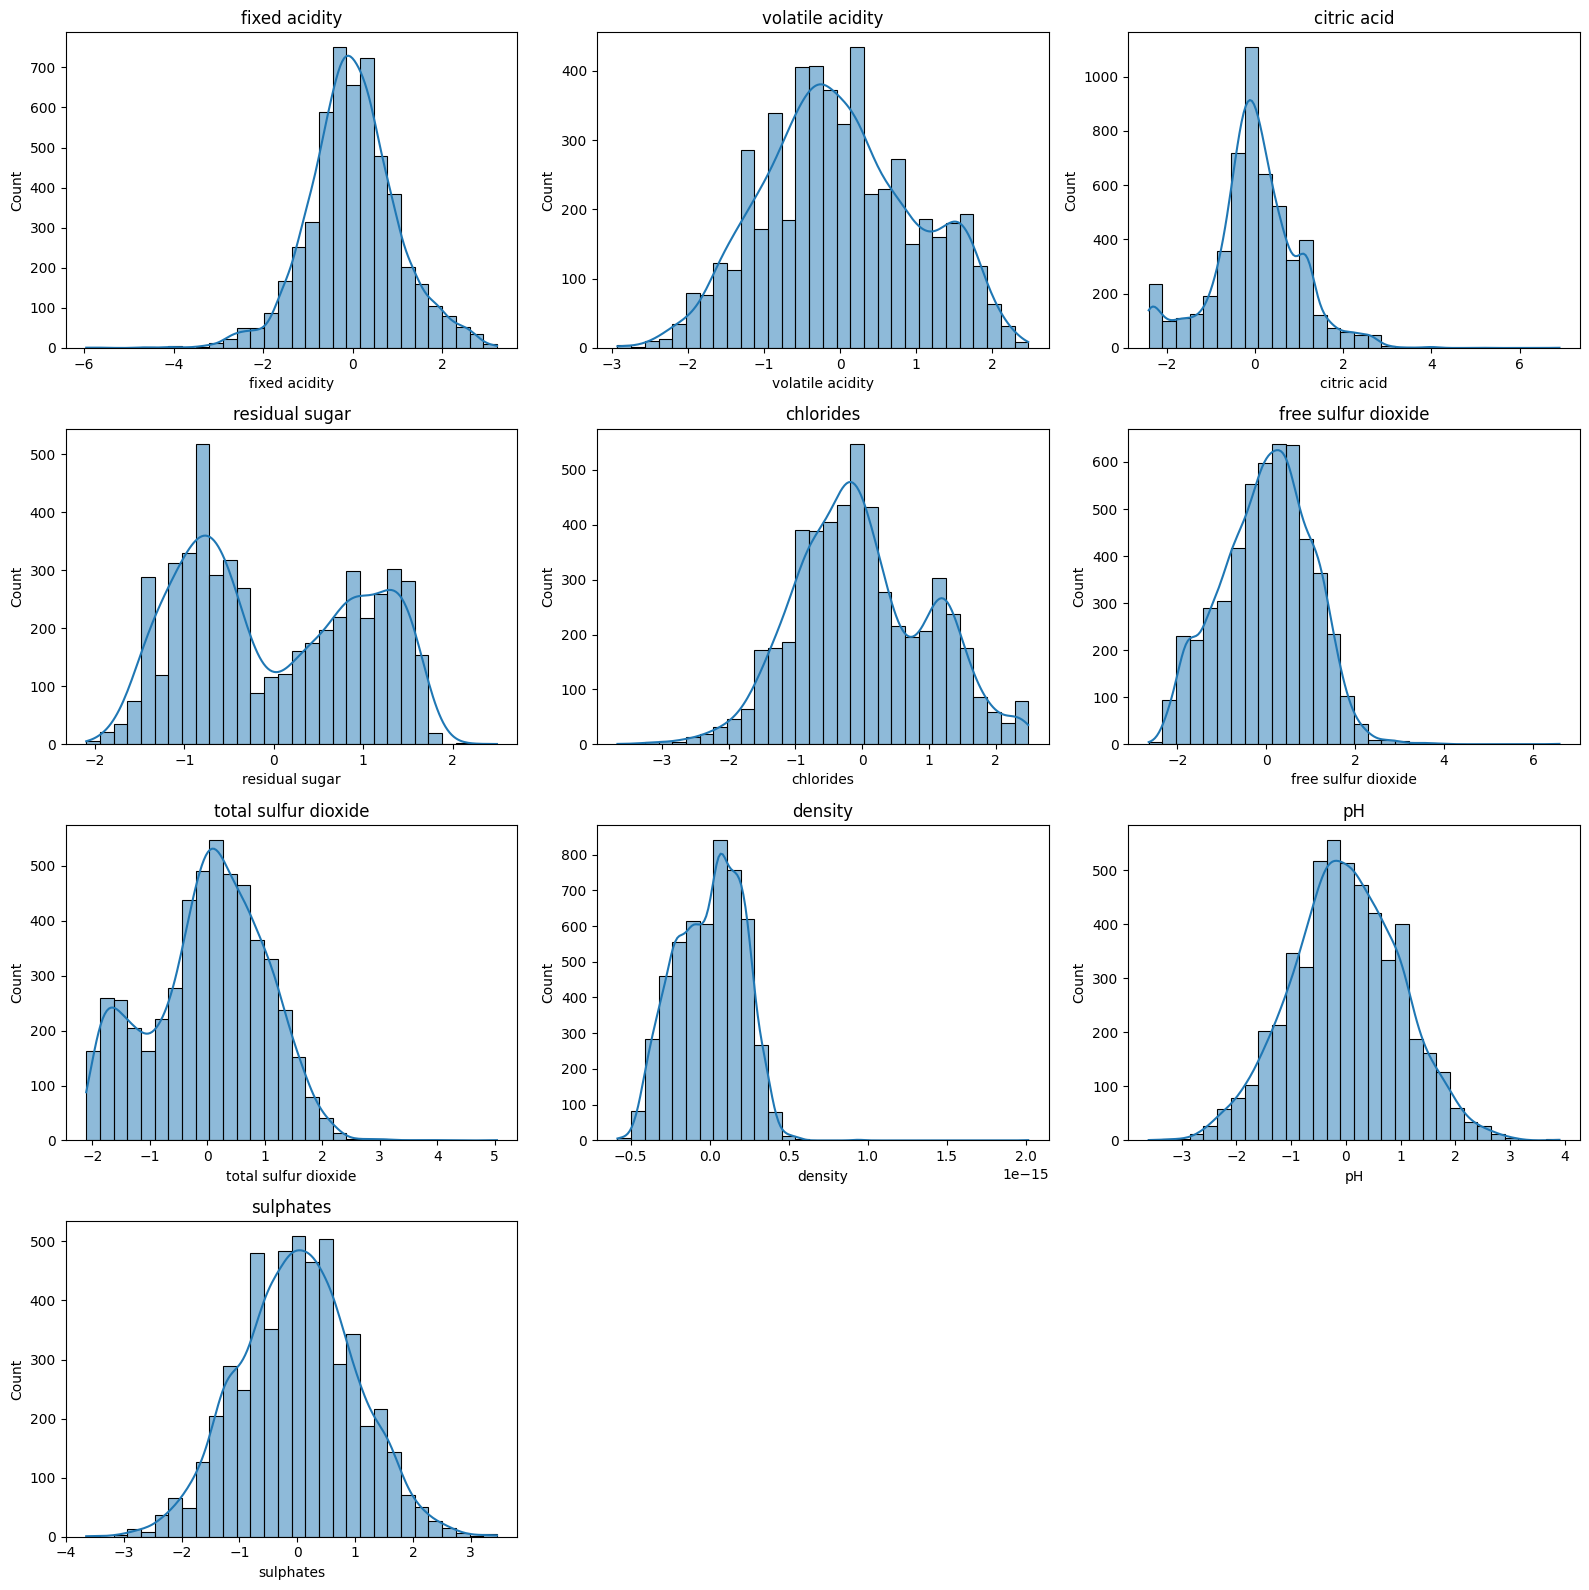

In [23]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(cols_a_transformar):
    sns.histplot(data=X_train_pt, x=col, kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)

for j in range(len(cols_a_transformar), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Ahora vamos a tratar el desequilibrio entre clases aplicando SMOTE.

In [25]:
from imblearn.over_sampling import SMOTE

# Revisar tamaño de la clase minoritaria en train
print(y_class_train.value_counts().sort_index())

# k_neighbors debe ser menor que el nº de muestras de la clase más pequeña
min_clase = y_class_train.value_counts().min()
k_neighbors = max(1, min_clase - 1)
print(f"k_neighbors usado: {k_neighbors}")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)

X_train_smote, y_class_train_smote = smote.fit_resample(X_train_pt, y_class_train)

print(y_class_train_smote.value_counts().sort_index())

quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64
k_neighbors usado: 3
quality
3    2269
4    2269
5    2269
6    2269
7    2269
8    2269
9    2269
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

modelos_clas = {
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(max_iter=5000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

cv_clas = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_recall = {}
resultados_f1 = {}

for nombre, modelo in modelos_clas.items():
    recall_scores = []
    f1_scores = []

    for train_idx, val_idx in cv_clas.split(X_train_pt, y_class_train):
        X_fold_train, X_fold_val = X_train_pt.iloc[train_idx], X_train_pt.iloc[val_idx]
        y_fold_train, y_fold_val = y_class_train.iloc[train_idx], y_class_train.iloc[val_idx]

        # SMOTE solo sobre el fold de entrenamiento
        min_clase_fold = y_fold_train.value_counts().min()
        k_fold = max(1, min(5, min_clase_fold - 1))
        smote_fold = SMOTE(random_state=42, k_neighbors=k_fold)
        X_fold_train_sm, y_fold_train_sm = smote_fold.fit_resample(X_fold_train, y_fold_train)

        modelo.fit(X_fold_train_sm, y_fold_train_sm)
        y_fold_pred = modelo.predict(X_fold_val)

        recall_scores.append(recall_score(y_fold_val, y_fold_pred, average='macro'))
        f1_scores.append(f1_score(y_fold_val, y_fold_pred, average='macro'))

    resultados_recall[nombre] = np.array(recall_scores)
    resultados_f1[nombre] = np.array(f1_scores)

    print(f"{nombre}: recall_macro = {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f}) "
          f"| f1_macro = {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


KNN: recall_macro = 0.3485 (+/- 0.0123) | f1_macro = 0.2879 (+/- 0.0025)


c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


LogisticRegression: recall_macro = 0.3226 (+/- 0.0623) | f1_macro = 0.1823 (+/- 0.0133)


c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


RandomForest: recall_macro = 0.3807 (+/- 0.0348) | f1_macro = 0.3831 (+/- 0.0309)


c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


GradientBoosting: recall_macro = 0.3212 (+/- 0.0157) | f1_macro = 0.2746 (+/- 0.0110)


Vamos a optimizar el random forest classifier, que obtuvo mejores métricas.

In [30]:
import random
random.seed(42)

# Espacio de hiperparámetros reducido
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Generar n_iter combinaciones aleatorias manualmente
n_iter = 15
combinaciones = []
for _ in range(n_iter):
    combo = {k: random.choice(v) for k, v in param_dist.items()}
    combinaciones.append(combo)

cv_clas = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_random = []

for params in combinaciones:
    fold_scores = []

    for train_idx, val_idx in cv_clas.split(X_train_pt, y_class_train):
        X_fold_train, X_fold_val = X_train_pt.iloc[train_idx], X_train_pt.iloc[val_idx]
        y_fold_train, y_fold_val = y_class_train.iloc[train_idx], y_class_train.iloc[val_idx]

        min_clase_fold = y_fold_train.value_counts().min()
        k_fold = max(1, min(5, min_clase_fold - 1))
        smote_fold = SMOTE(random_state=42, k_neighbors=k_fold)
        X_fold_train_sm, y_fold_train_sm = smote_fold.fit_resample(X_fold_train, y_fold_train)

        modelo = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
        modelo.fit(X_fold_train_sm, y_fold_train_sm)
        y_fold_pred = modelo.predict(X_fold_val)

        fold_scores.append(recall_score(y_fold_val, y_fold_pred, average='macro'))

    media_recall = np.mean(fold_scores)
    resultados_random.append({**params, 'recall_macro_medio': media_recall, 'recall_macro_std': np.std(fold_scores)})

resultados_random_df = pd.DataFrame(resultados_random).sort_values('recall_macro_medio', ascending=False)
print(resultados_random_df.head(10))

c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sa

    n_estimators  max_depth  min_samples_split  min_samples_leaf  \
8            200       20.0                  5                 1   
5            100       20.0                 10                 1   
7            300       20.0                  5                 1   
10           200        NaN                  2                 2   
11           100        NaN                  5                 1   
3            300        NaN                 10                 2   
0            300        NaN                  2                 4   
4            100        NaN                  2                 1   
9            100       20.0                  5                 2   
1            200        NaN                  2                 1   

    recall_macro_medio  recall_macro_std  
8             0.387992          0.033062  
5             0.387620          0.041186  
7             0.387613          0.034144  
10            0.387218          0.035804  
11            0.386950          0.03

In [31]:
mejores_params = resultados_random_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']].to_dict()

# Asegurar tipos correctos (a veces quedan como float tras pasar por DataFrame)
mejores_params['n_estimators'] = int(mejores_params['n_estimators'])
mejores_params['min_samples_split'] = int(mejores_params['min_samples_split'])
mejores_params['min_samples_leaf'] = int(mejores_params['min_samples_leaf'])
if mejores_params['max_depth'] is not None and not pd.isna(mejores_params['max_depth']):
    mejores_params['max_depth'] = int(mejores_params['max_depth'])

print("Mejores hiperparámetros:", mejores_params)
print("Mejor recall_macro (CV):", resultados_random_df.iloc[0]['recall_macro_medio'])

Mejores hiperparámetros: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1}
Mejor recall_macro (CV): 0.387992229540162


In [32]:
mejores_params = resultados_random_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']].to_dict()

# Asegurar tipos correctos (a veces quedan como float tras pasar por DataFrame)
mejores_params['n_estimators'] = int(mejores_params['n_estimators'])
mejores_params['min_samples_split'] = int(mejores_params['min_samples_split'])
mejores_params['min_samples_leaf'] = int(mejores_params['min_samples_leaf'])
if mejores_params['max_depth'] is not None and not pd.isna(mejores_params['max_depth']):
    mejores_params['max_depth'] = int(mejores_params['max_depth'])

print("Mejores hiperparámetros:", mejores_params)
print("Mejor recall_macro (CV):", resultados_random_df.iloc[0]['recall_macro_medio'])

Mejores hiperparámetros: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1}
Mejor recall_macro (CV): 0.387992229540162


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.21      0.30      0.25        43
           5       0.70      0.68      0.69       428
           6       0.68      0.65      0.66       567
           7       0.59      0.60      0.60       216
           8       0.39      0.44      0.41        39
           9       0.00      0.00      0.00         1

    accuracy                           0.63      1300
   macro avg       0.37      0.38      0.37      1300
weighted avg       0.64      0.63      0.64      1300



c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

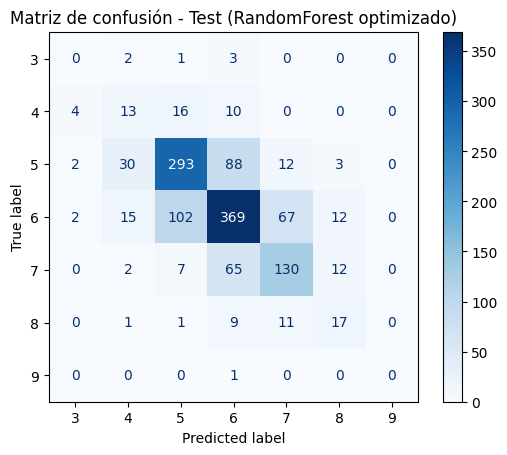

In [35]:
# SMOTE sobre todo el train para el modelo final
min_clase = y_class_train.value_counts().min()
k_final = max(1, min(5, min_clase - 1))
smote_final = SMOTE(random_state=42, k_neighbors=k_final)
X_train_final_sm, y_class_train_final_sm = smote_final.fit_resample(X_train_pt, y_class_train)

# Entrenar modelo final con los mejores hiperparámetros encontrados
modelo_final = RandomForestClassifier(random_state=42, n_jobs=-1, **mejores_params)
modelo_final.fit(X_train_final_sm, y_class_train_final_sm)

# Predecir sobre test (sin tocar, sin SMOTE)
y_pred_test = modelo_final.predict(X_test_pt)

print(classification_report(y_class_test, y_pred_test))

cm = confusion_matrix(y_class_test, y_pred_test)
ConfusionMatrixDisplay(cm, display_labels=sorted(y_class_test.unique())).plot(cmap='Blues')
plt.title('Matriz de confusión - Test (RandomForest optimizado)')
plt.show()

Hay algunas clases que siguen sin poder clasificarse bien. Posibilidad de recategorización en solo 3 grupos para dar robustez estadística.

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [36]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.model_selection import KFold

modelos_reg = {
    'KNN': KNeighborsRegressor(),
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
resultados_reg = {}

for nombre, modelo in modelos_reg.items():
    fold_scores = []

    for train_idx, val_idx in cv_reg.split(X_train_pt):
        X_fold_train, X_fold_val = X_train_pt.iloc[train_idx], X_train_pt.iloc[val_idx]
        y_fold_train, y_fold_val = y_reg_train.iloc[train_idx], y_reg_train.iloc[val_idx]

        modelo.fit(X_fold_train, y_fold_train)
        y_fold_pred = modelo.predict(X_fold_val)

        fold_scores.append(mean_absolute_percentage_error(y_fold_val, y_fold_pred))

    resultados_reg[nombre] = np.array(fold_scores)
    print(f"{nombre}: MAPE medio = {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

KNN: MAPE medio = 0.0536 (+/- 0.0008)
LinearRegression: MAPE medio = 0.0704 (+/- 0.0014)
RandomForest: MAPE medio = 0.0470 (+/- 0.0014)
GradientBoosting: MAPE medio = 0.0594 (+/- 0.0011)


Random forest vuelve a ser en este caso el mejor modelo, así que pasamos a optimizarlo.

In [37]:
from sklearn.model_selection import RandomizedSearchCV

# Espacio de hiperparámetros
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_percentage_error',
    cv=cv_reg,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_pt, y_reg_train)

print("Mejores hiperparámetros:", random_search.best_params_)
print("Mejor MAPE (CV):", -random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}
Mejor MAPE (CV): 0.04800880202185885


In [38]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

modelo_reg_final = random_search.best_estimator_
y_pred_reg_test = modelo_reg_final.predict(X_test_pt)

mape_test = mean_absolute_percentage_error(y_reg_test, y_pred_reg_test)
mae_test = mean_absolute_error(y_reg_test, y_pred_reg_test)
r2_test = r2_score(y_reg_test, y_pred_reg_test)

print(f"MAPE (test): {mape_test:.4f}")
print(f"MAE (test): {mae_test:.4f}")
print(f"R2 (test): {r2_test:.4f}")

MAPE (test): 0.0470
MAE (test): 0.5063
R2 (test): 0.6578


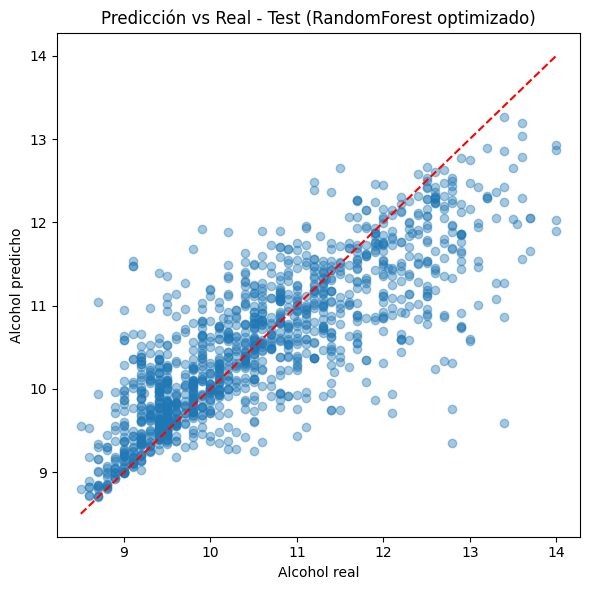

In [39]:
plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, y_pred_reg_test, alpha=0.4)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--')
plt.xlabel('Alcohol real')
plt.ylabel('Alcohol predicho')
plt.title('Predicción vs Real - Test (RandomForest optimizado)')
plt.tight_layout()
plt.show()

Vemos que más o menos se ajustan a la recta, aunque en valores superiores la dispersión aumenta.

In [40]:
# Construir tabla de análisis (usamos X_test sin transformar para que las variables sean interpretables)
analisis_reg = X_test.copy()
analisis_reg['alcohol_real'] = y_reg_test.values
analisis_reg['alcohol_pred'] = y_pred_reg_test
analisis_reg['error_abs'] = np.abs(analisis_reg['alcohol_real'] - analisis_reg['alcohol_pred'])
analisis_reg['error_pct'] = analisis_reg['error_abs'] / analisis_reg['alcohol_real']

print(analisis_reg[['alcohol_real', 'alcohol_pred', 'error_abs', 'error_pct']].describe())

       alcohol_real  alcohol_pred    error_abs    error_pct
count   1300.000000   1300.000000  1300.000000  1300.000000
mean      10.545108     10.516571     0.506299     0.046979
std        1.221676      0.915706     0.504108     0.044858
min        8.500000      8.699304     0.000411     0.000043
25%        9.500000      9.791938     0.134031     0.013146
50%       10.400000     10.449784     0.347824     0.033288
75%       11.400000     11.148069     0.746778     0.070849
max       14.000000     13.263597     3.813537     0.284592


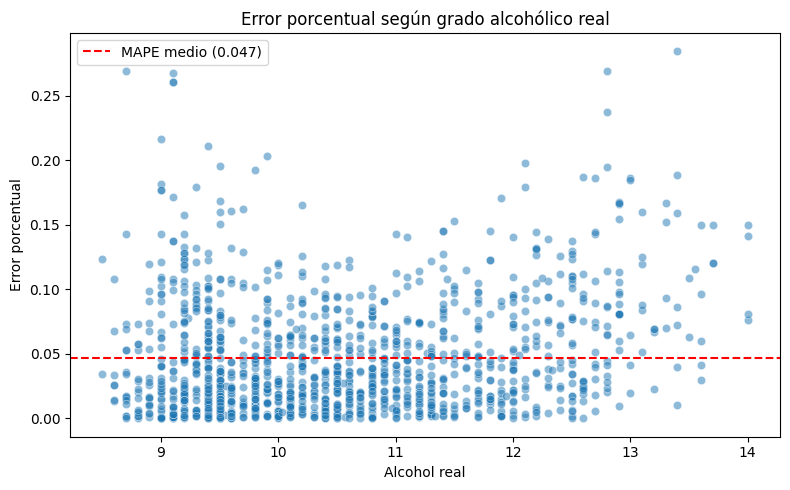

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=analisis_reg, x='alcohol_real', y='error_pct', alpha=0.5)
plt.axhline(mape_test, color='red', linestyle='--', label=f'MAPE medio ({mape_test:.3f})')
plt.xlabel('Alcohol real')
plt.ylabel('Error porcentual')
plt.title('Error porcentual según grado alcohólico real')
plt.legend()
plt.tight_layout()
plt.show()

Los mayores errores se dan en valores menores a 10 y mayores a 12, por lo que aumentar el numero de muestras en estos rangos podría mejorar los resulttados.